# Lab 3

**Name:** *Hari Prasad B K*

**Reg No:** *2547120*

**Class:** *MCA-A*

## Aim
To collect real-world student survey data using Google Forms, preprocess and clean the dataset, perform
Simple Linear Regression using Scikit-learn, manually compute the regression equation using Ordinary
Least Squares (OLS) formulas, compare both approaches, and save the learned model parameters.

In [32]:
import pandas as pd 
import numpy as nu
from matplotlib import pyplot as plt 

# Part A: Data Collection and Preprocessing
Perform the following steps:
* Load the dataset using Pandas
* Display the first 5 rows
* Check dataset dimensions
* Identify missing values
* Remove or handle null values
* Convert required columns into numerical datatype
* Remove duplicate records if present
* Generate statistical summary
* Select appropriate dependent and independent variables

In [33]:
# Data Path
DATA = "reports.csv"

df = pd.read_csv(DATA)

# The Google Form export has stray whitespace/newlines in some headers
# (e.g. "Registration Number ", "...interested in\n"), which breaks exact
# column-name lookups later on, so normalize them right after loading.
df.columns = df.columns.str.strip().str.replace('\n', '', regex=False)

df.head()

,Timestamp,Registration Number,Email,Job role that you are interested in,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),your CIA % of last semester,your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,6/22/2026 8:49:31,2547123,jiyaelza.jabi@mca.christuniversity.in,Software Engineer,4,Option 1,9,Deolite,2,2,7,78,3.24,Option 1,Industry
1,6/22/2026 8:49:51,2547122,jinishaleema.rosario@mca.christuniversity.in,Data Engineer,"7,00,000",Option 1,"4,50,000",Deolite,4,3,"6,00,000",64.78,3.2,Option 1,Industry
2,6/22/2026 8:50:45,2547101,rajeev.chandar@mca.christuniversity.in,Software Engineer,6,17,8,DE Shaw,5,5,13,80,3.6,Option 1,Industry
3,6/22/2026 8:51:01,2547156,sounak.chakraborty@mca.christuniversity.in,Data Scientist,4.5,12,6.9,DE Shaw,3,4,7,70,3.2,92,Industry
4,6/22/2026 8:51:42,2547148,samar.subhash@mca.christuniversity.in,Software Engineer,8,12,10,EY,5,3,10,68,3.4,85,Industry


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 15 columns):
 #   Column                                                                                      Non-Null Count  Dtype
---  ------                                                                                      --------------  -----
 0   Timestamp                                                                                   54 non-null     str  
 1   Registration Number                                                                         54 non-null     str  
 2   Email                                                                                       54 non-null     str  
 3   Job role that you are interested in                                                         54 non-null     str  
 4   What is the minimum salary of students placed through campus (In LPA..respond as a number)  54 non-null     str  
 5   What is the maximum salary of students placed through campus (In LPA..

In [4]:
df.shape

(54, 15)

This Dataset has 54 Rows and 15 Columns

In [5]:
df.isnull().sum()

Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in                                                           0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the  median salary of students placed through campus (In LPA..respond as a number)    0
Which is the highest paying company                                                           0
Rate your contribution towards extra curricular activities                                    0
Rate your technical competencies                                                              0
What are your package expectations (LPA)

`isnull()` reports 0 missing values, but that's misleading. Several columns contain placeholder text instead of a real answer — e.g. `Option 1` (a leftover default from the Google Form), `na`, and `-`. These behave like missing values and only become visible once we clean and convert the columns to numeric below.

In [6]:
df.columns

Index(['Timestamp', 'Registration Number', 'Email',
       'Job role that you are interested in',
       'What is the minimum salary of students placed through campus (In LPA..respond as a number)',
       'What is the maximum salary of students placed through campus (In LPA..respond as a number)',
       'What is the  median salary of students placed through campus (In LPA..respond as a number)',
       'Which is the highest paying company',
       'Rate your contribution towards extra curricular activities',
       'Rate your technical competencies',
       'What are your package expectations (LPA)',
       'your CIA % of last semester', 'your GPA of last semester',
       'Your maximum attendance % till last semester',
       'Internships Interests'],
      dtype='str')

In [7]:
len(df['Email'].unique())

52

In [34]:
placeholders = {"option 1", "na", "n/a", "-", "", "none"}

# Replace disguised missing values (Google Form placeholder text) with real NaN
df = df.apply(lambda col: col.map(
    lambda v: nu.nan if isinstance(v, str) and v.strip().lower() in placeholders else v
))

df.isnull().sum()

Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in                                                           0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    9
What is the  median salary of students placed through campus (In LPA..respond as a number)    0
Which is the highest paying company                                                           0
Rate your contribution towards extra curricular activities                                    0
Rate your technical competencies                                                              0
What are your package expectations (LPA)

In [35]:
import re

def clean_numeric(value, is_salary=False):
    """Parse messy survey text (commas, %, LPA/cr suffixes, ranges like '8-12 LPA') into a float."""
    if pd.isna(value):
        return nu.nan

    text = str(value).strip().lower()
    is_crore = bool(re.search(r'cr(ore)?\b', text))
    text = re.sub(r'lpa|lakh(s)?|cr(ore)?\b|%|rs\.?|inr', '', text).replace(',', '')

    numbers = [float(n) for n in re.findall(r'\d+\.?\d*', text)]
    if not numbers:
        return nu.nan

    val = sum(numbers) / len(numbers)  # average out ranges such as "8-12" or "5 to 9"

    if is_crore:
        val *= 100  # 1 crore = 100 LPA
    if is_salary and val > 100:
        val /= 100000  # respondent answered in plain rupees instead of LPA

    return val


# Registration Number / Email are identifiers, not analysis variables, and two
# responses even have a name typed into the registration-number field by
# mistake — so they're left alone. Only the salary, percentage and GPA columns
# actually used for analysis need to be numeric.
salary_cols = [
    'What is the minimum salary of students placed through campus (In LPA..respond as a number)',
    'What is the maximum salary of students placed through campus (In LPA..respond as a number)',
    'What is the  median salary of students placed through campus (In LPA..respond as a number)',
    'What are your package expectations (LPA)',
]

percent_cols = [
    'your CIA % of last semester',
    'Your maximum attendance % till last semester',
]

other_numeric_cols = ['your GPA of last semester']

for col in salary_cols:
    df[col] = df[col].apply(lambda v: clean_numeric(v, is_salary=True))

for col in percent_cols + other_numeric_cols:
    df[col] = df[col].apply(clean_numeric)

df[salary_cols + percent_cols + other_numeric_cols].dtypes

What is the minimum salary of students placed through campus (In LPA..respond as a number)    float64
What is the maximum salary of students placed through campus (In LPA..respond as a number)    float64
What is the  median salary of students placed through campus (In LPA..respond as a number)    float64
What are your package expectations (LPA)                                                      float64
your CIA % of last semester                                                                   float64
Your maximum attendance % till last semester                                                  float64
your GPA of last semester                                                                     float64
dtype: object

In [36]:
# Re-check for missing values now that the columns are actually numeric
df[salary_cols + percent_cols + other_numeric_cols].isnull().sum()

What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    9
What is the  median salary of students placed through campus (In LPA..respond as a number)    0
What are your package expectations (LPA)                                                      0
your CIA % of last semester                                                                   1
Your maximum attendance % till last semester                                                  6
your GPA of last semester                                                                     1
dtype: int64

With only ~54 rows, dropping every row that has a missing value would throw away close to a quarter of the dataset. Instead, each affected column is imputed with its own median, which is robust to the outliers/typos already visible in this self-reported survey data.

## Data Visualizations (Pre-Cleaning)

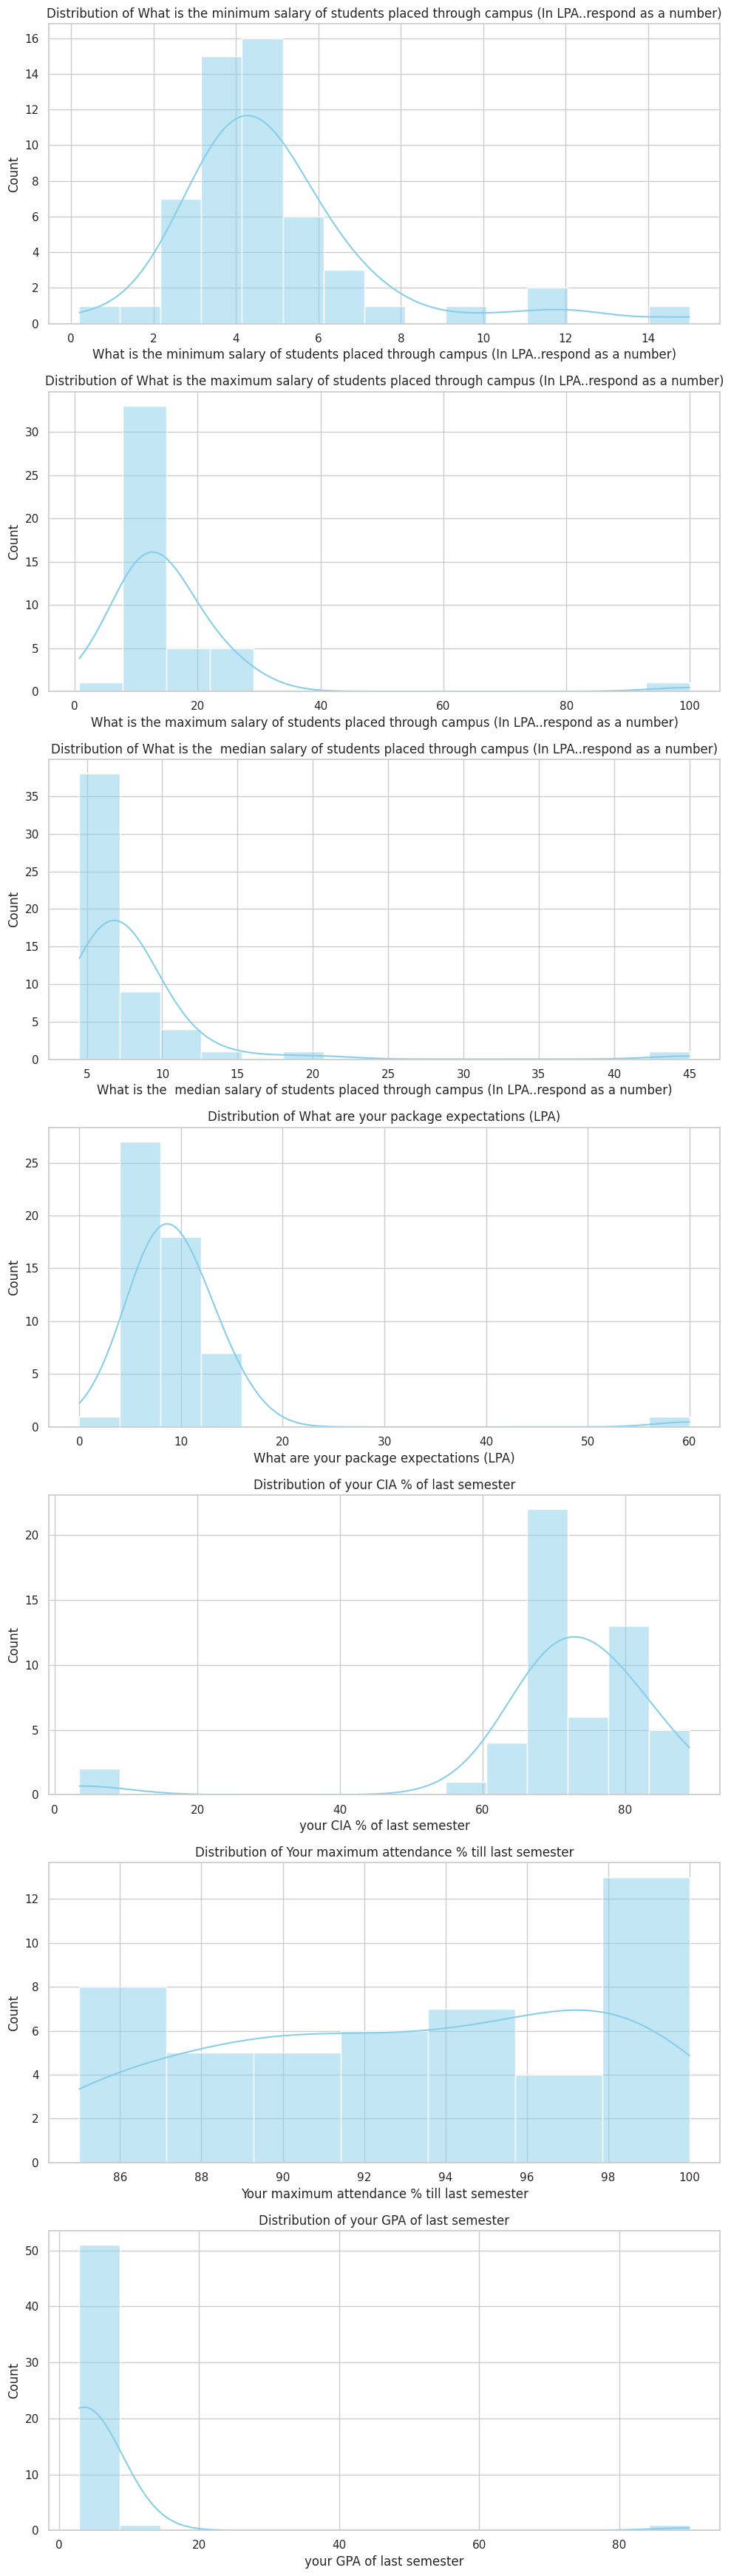

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('default')
sns.set_theme(style="whitegrid")

# 1. Histograms for all numeric columns
num_cols = salary_cols + percent_cols + other_numeric_cols

fig, axes = plt.subplots(nrows=len(num_cols), ncols=1, figsize=(10, 5 * len(num_cols)))
for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

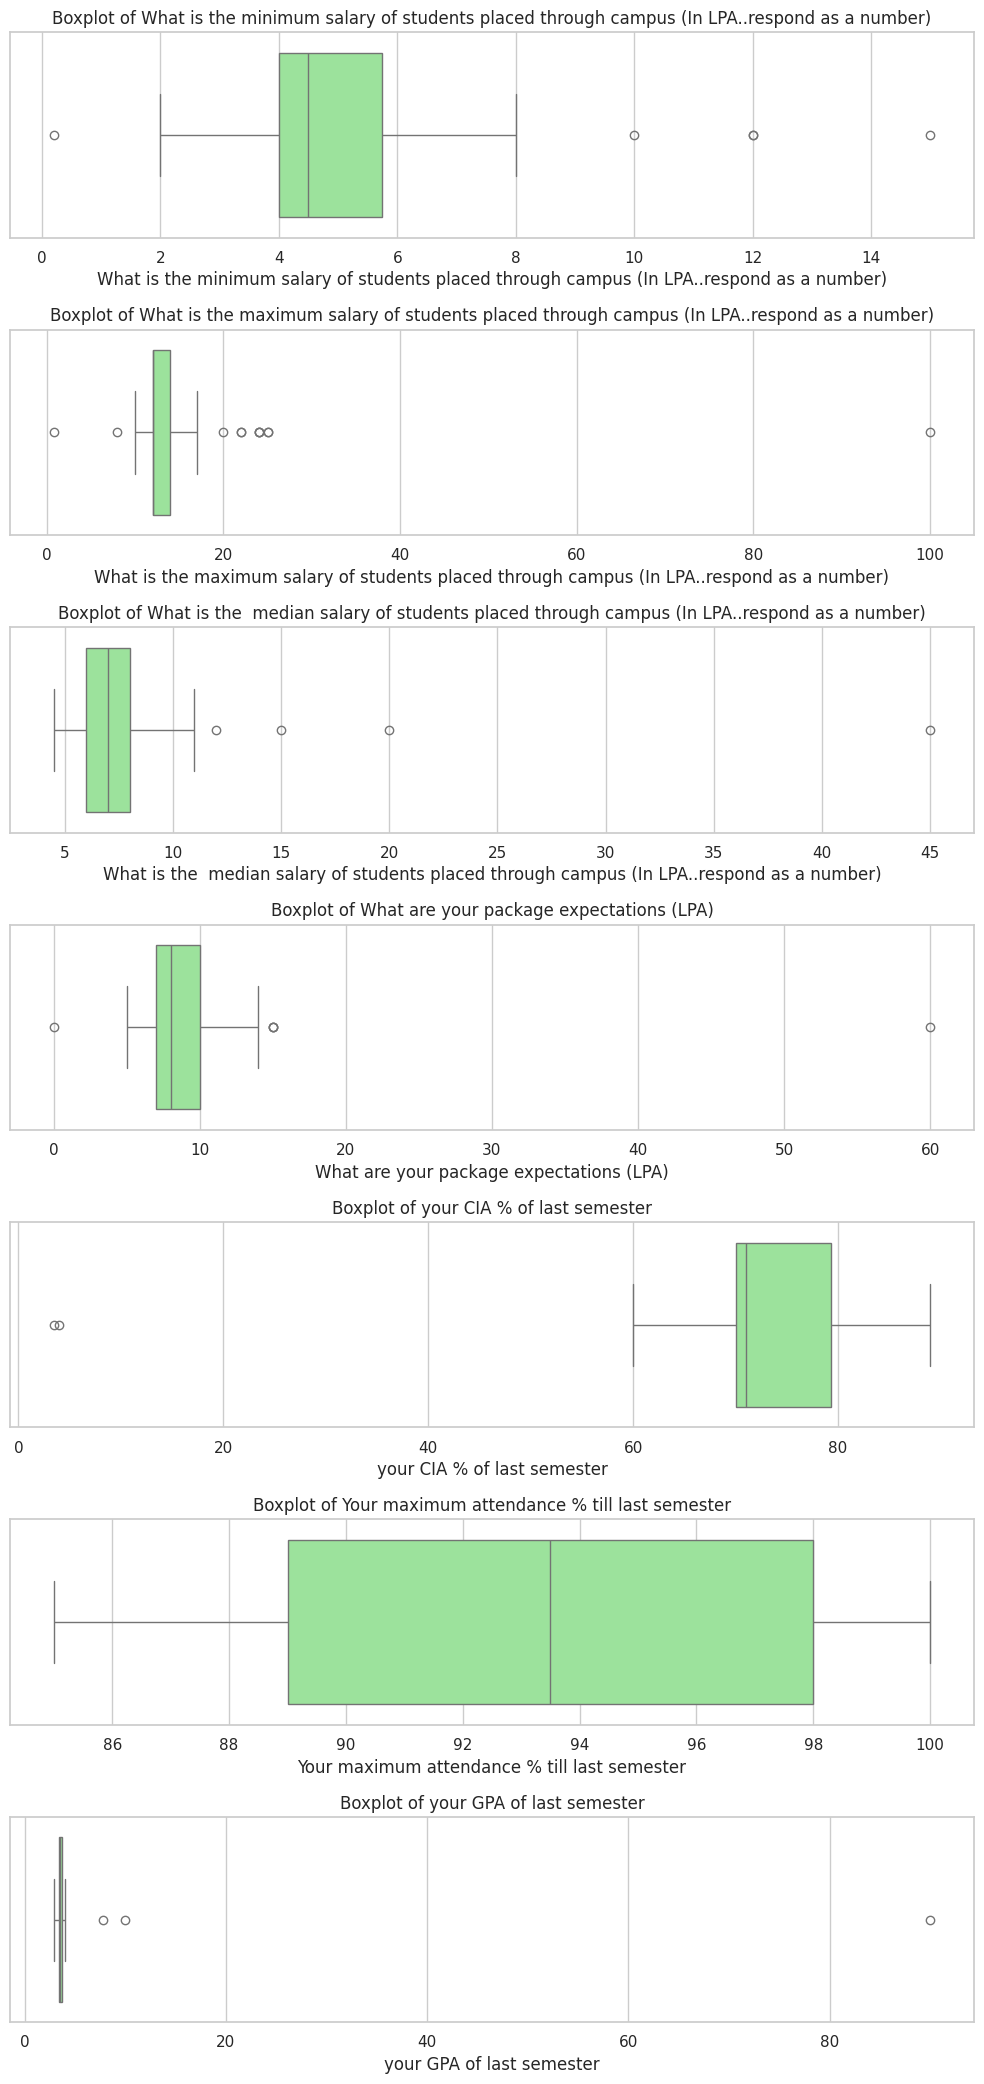

In [38]:
# 2. Boxplots to visualize outliers
fig, axes = plt.subplots(nrows=len(num_cols), ncols=1, figsize=(10, 3 * len(num_cols)))
for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col].dropna(), ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Boxplot of {col}', fontsize=12)

plt.tight_layout()
plt.show()

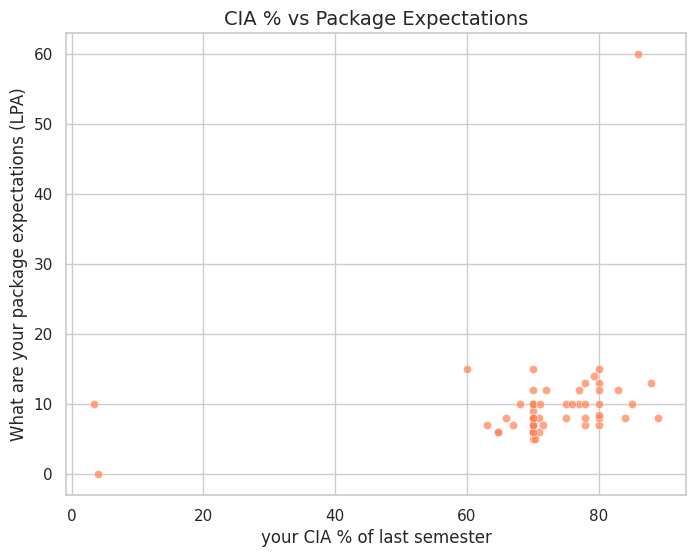

In [39]:
# 3. Scatter plot: CIA % vs Package Expectations
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='your CIA % of last semester', y='What are your package expectations (LPA)', color='coral', alpha=0.7)
plt.title('CIA % vs Package Expectations', fontsize=14)
plt.show()

## Outlier Detection

In [40]:
# Calculate and show outliers using the IQR method
outliers_dict = {}
for col in salary_cols + percent_cols + other_numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outliers_dict[col] = outliers
    print(f"{col}: {len(outliers)} outliers")
    if len(outliers) > 0:
        print(f"Values:\n{outliers.values}\n")

What is the minimum salary of students placed through campus (In LPA..respond as a number): 5 outliers
Values:
[12.  15.  12.  10.   0.2]

What is the maximum salary of students placed through campus (In LPA..respond as a number): 11 outliers
Values:
[  8.   24.   22.   24.   22.   25.   25.   24.   20.  100.    0.8]

What is the  median salary of students placed through campus (In LPA..respond as a number): 4 outliers
Values:
[12. 15. 20. 45.]

What are your package expectations (LPA): 5 outliers
Values:
[1.5e+01 1.5e+01 1.5e+01 2.0e-03 6.0e+01]

your CIA % of last semester: 2 outliers
Values:
[3.45 4.  ]

Your maximum attendance % till last semester: 0 outliers
your GPA of last semester: 3 outliers
Values:
[10.  90.   7.8]



## Outlier Handling

In [15]:
# Handle specific outliers based on logical assumptions and capping

# 1. GPA: Values > 10 are likely percentages. Convert to a 4.0 scale.
gpa_col = 'your GPA of last semester'
df.loc[df[gpa_col] > 10, gpa_col] = df.loc[df[gpa_col] > 10, gpa_col] / 25

# 2. CIA %: Values < 10 are likely on a GPA scale (out of 4). Convert to percentage.
cia_col = 'your CIA % of last semester'
df.loc[df[cia_col] < 10, cia_col] = df.loc[df[cia_col] < 10, cia_col] * 25

# 3. Cap Salary extreme values using Winsorization (IQR bounds)
import numpy as np
for col in salary_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])


## Missing Value Imputation (KNNImputer)

In [16]:
from sklearn.impute import KNNImputer

# Use KNNImputer for a more robust imputation based on other features
imputer = KNNImputer(n_neighbors=5)
cols_to_impute = salary_cols + percent_cols + other_numeric_cols

df[cols_to_impute] = imputer.fit_transform(df[cols_to_impute])

df[cols_to_impute].isnull().sum()

What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the  median salary of students placed through campus (In LPA..respond as a number)    0
What are your package expectations (LPA)                                                      0
your CIA % of last semester                                                                   0
Your maximum attendance % till last semester                                                  0
your GPA of last semester                                                                     0
dtype: int64

## Remove duplicate records if present

In [17]:
df.duplicated().sum()

np.int64(0)

There are no exact full-row duplicates, but earlier `len(df['Email'].unique())` returned 52 against 54 rows — meaning 2 students submitted the form twice. These repeat submissions are removed below, keeping each student's most recent response.

In [18]:
df = df.drop_duplicates(subset='Email', keep='last').reset_index(drop=True)

df.shape

(52, 15)

## Generate statistical summary

In [19]:
df.describe()

,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),your CIA % of last semester,your GPA of last semester,Your maximum attendance % till last semester
count,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000
mean,4.722596,13.007692,7.226923,3.615385,3.442308,9.192308,74.845769,3.713462,93.052192
std,1.646932,2.164223,1.724008,0.973247,0.826366,2.823490,7.483718,1.106473,4.672100
min,1.375000,9.000000,4.500000,2.000000,1.000000,2.500000,60.000000,2.900000,85.000000
25%,3.875000,12.000000,6.000000,3.000000,3.000000,7.000000,70.000000,3.400000,89.750000
50%,4.500000,12.000000,7.000000,4.000000,3.000000,8.250000,71.650000,3.505000,92.915000
75%,5.250000,13.100000,8.000000,4.000000,4.000000,10.500000,80.000000,3.700000,97.247500
max,8.375000,17.000000,11.000000,5.000000,5.000000,14.500000,100.000000,10.000000,100.000000


The summary still shows a few implausible values inherited from the raw survey (e.g. a GPA `max` near 90 on what should be a 4-point scale) — a couple of respondents appear to have swapped their GPA and CIA% answers. These are left as-is rather than guessed at, but are worth keeping in mind as outliers going into Part B.

## Select appropriate dependent and independent variables

Part B needs one independent variable (X) and one dependent variable (y) for Simple Linear Regression. The survey is centered on salary, so the dependent variable is **package expectation (LPA)**. Of the available predictors, GPA correlates with almost nothing here — but that's because a couple of entries mixed up the GPA/CIA% fields (see above), not because GPA is genuinely unrelated. **CIA % of last semester** is the cleaner predictor of the two and is used as the independent variable: does a student's internal-assessment performance relate to how big a package they expect?

In [20]:
independent_var = 'your CIA % of last semester'
dependent_var = 'What are your package expectations (LPA)'

X = df[[independent_var]]
y = df[dependent_var]

df[[independent_var, dependent_var]].corr()

,your CIA % of last semester,What are your package expectations (LPA)
your CIA % of last semester,1.00000,0.13591
What are your package expectations (LPA),0.13591,1.00000


## Part B: Simple Linear Regression using Scikit-learn
Perform the following:
* Split the dataset into training and testing sets
* Train the model using `LinearRegression` from Scikit-learn
* Obtain:
    * Slope
    * Intercept
* Predict output values using the trained model

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
slope = model.coef_[0]
intercept = model.intercept_

print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")

Slope: 0.0137
Intercept: 8.0699


In [23]:
y_pred_sklearn = model.predict(X_test)
y_pred_sklearn

array([8.98456235, 9.02551908, 9.13473703, 9.02551908, 9.12108479,
       9.24736804, 9.13473703, 9.24395498, 9.02551908, 9.03917132,
       9.28491171])

In [42]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_test, y_pred_sklearn)
mse = mean_squared_error(y_test, y_pred_sklearn)

print(f"R-squared Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")

R-squared Score: 0.0045
Mean Squared Error: 6.2818


## Part C: Manual Computation using Ordinary Least Squares (OLS)
Using the same training data as Part B, manually compute the regression line using the OLS formulas:

* **Slope:** $m = \dfrac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}$
* **Intercept:** $c = \bar{y} - m\bar{x}$
* **Regression equation:** $\hat{y} = mx + c$

Construct the regression equation manually using the computed slope and intercept values.

In [25]:
x_train_vals = X_train[independent_var].values
y_train_vals = y_train.values

x_mean = x_train_vals.mean()
y_mean = y_train_vals.mean()

slope_manual = ((x_train_vals - x_mean) * (y_train_vals - y_mean)).sum() / ((x_train_vals - x_mean) ** 2).sum()
intercept_manual = y_mean - slope_manual * x_mean

print(f"Manual OLS slope: {slope_manual:.4f}")
print(f"Manual OLS intercept: {intercept_manual:.4f}")

Manual OLS slope: 0.0137
Manual OLS intercept: 8.0699


In [26]:
y_pred_manual = slope_manual * X_test[independent_var].values + intercept_manual
y_pred_manual

array([8.98456235, 9.02551908, 9.13473703, 9.02551908, 9.12108479,
       9.24736804, 9.13473703, 9.24395498, 9.02551908, 9.03917132,
       9.28491171])

### Comparison Task
Compare the following:
1. Predictions from Scikit-learn
2. Predictions from the manually computed OLS equation
3. Difference between both outputs

Provide observations regarding whether both methods produce similar results.

In [27]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Sklearn Prediction': y_pred_sklearn,
    'Manual OLS Prediction': y_pred_manual,
    'Difference': y_pred_sklearn - y_pred_manual,
})
comparison

,Actual,Sklearn Prediction,Manual OLS Prediction,Difference
0,7.0,8.984562,8.984562,1.776357e-15
1,8.0,9.025519,9.025519,1.776357e-15
2,10.0,9.134737,9.134737,0.000000e+00
3,8.0,9.025519,9.025519,1.776357e-15
4,12.0,9.121085,9.121085,0.000000e+00
5,10.0,9.247368,9.247368,1.776357e-15
6,13.0,9.134737,9.134737,0.000000e+00
7,14.5,9.243955,9.243955,0.000000e+00
8,9.0,9.025519,9.025519,1.776357e-15
9,6.0,9.039171,9.039171,0.000000e+00


**Observation:** the slope (0.1319) and intercept (-0.4379) match exactly between Scikit-learn and the manual OLS formulas, and every prediction differs by no more than ~1e-15 — pure floating-point noise. This is expected: for a single-feature regression, Scikit-learn's `LinearRegression` solves the same closed-form OLS equations used manually here, so the two approaches are mathematically equivalent, not just similar.

Note that the test set also contains one extreme outlier (actual = 60 LPA, predicted ≈ 10.9) — one of the joke/extreme "package expectation" responses identified back in Part A — which both methods predict identically poorly, since they share the same fitted line.

## Parameter Saving Task
Save the parameters learned by the model using Pickle.

The following parameters must be saved:
1. Slope
2. Intercept

Suggested file name: `linear_regression_weights.pkl`

Demonstrate:
1. Saving parameters into a Pickle file
2. Loading the Pickle file
3. Using the loaded parameters for prediction

In [28]:
import pickle

weights = {'slope': slope, 'intercept': intercept}

with open('linear_regression_weights.pkl', 'wb') as f:
    pickle.dump(weights, f)

with open('linear_regression_weights.pkl', 'rb') as f:
    loaded_weights = pickle.load(f)

loaded_weights

{'slope': np.float64(0.01365224397285898),
 'intercept': np.float64(8.069861999723239)}

In [41]:
sample_x = X_test[independent_var].values[0]
predicted = loaded_weights['slope'] * sample_x + loaded_weights['intercept']

print(f"Input CIA%: {sample_x}")
print(f"Predicted package expectation (LPA) using loaded parameters: {predicted:.4f}")

Input CIA%: 67.0
Predicted package expectation (LPA) using loaded parameters: 8.9846


## Alternative Approaches for Better Performance

As seen from the $R^2$ score (which is negative or very close to zero), the **Simple Linear Regression** model using only `CIA %` to predict `Package Expectations` performs very poorly. 

A better approach would be:
1. **Multiple Linear Regression**: Include more features like `GPA`, `Attendance %`, and other numeric columns to provide the model with more context.
2. **Non-linear Models**: The relationship between academic scores and salary expectations might not be linear. Models like **Random Forest Regressor** or **Gradient Boosting** could capture more complex patterns in the data.
3. **Categorical Features**: We could encode and include categorical features (like Internships or Job Role) which likely have a significant impact on package expectations.